# Validation — Roll's Model vs Order-Book Spread
**Owner: S**

Run `estimate_spread()` on each ticker/day, compare to the actual 1-Hz order-book spread, and produce the metrics table and time-series plots for the presentation.

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.preprocessing import load_trades
from src.estimate_spread import estimate_spread
from src.validation import compute_ob_spread, evaluate, print_evaluation_table

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

## Configuration
Adjust `WINDOW` below (or run the grid-search cell) and `TICKERS`/`DATES` if needed.

In [9]:
TICKERS = ['WIFUSDT', 'ZAMAUSDT']
DATES = ['2026-04-12', '2026-04-13', '2026-04-14']
WINDOW = 30  # seconds — tune with cross-validation below

## 1 — Window Cross-Validation (Apr 12 + 13 → Apr 14)

In [10]:
WINDOWS = [30, 60, 90, 120, 180, 300]
cv_results = {ticker: {} for ticker in TICKERS}

for ticker in TICKERS:
    print(f'\n=== {ticker} — CV on Apr 12–13, eval on Apr 13 ===')
    trades_val = load_trades(ticker, '2026-04-13')
    ob_val = compute_ob_spread(ticker, '2026-04-13')

    rows = []
    for w in WINDOWS:
        est = estimate_spread(trades_val['price'], trades_val['amount'], window=w)
        m = evaluate(est, ob_val)
        rows.append({'window': w, **m})

    df_cv = pd.DataFrame(rows).set_index('window')
    cv_results[ticker] = df_cv
    display(df_cv[['mae', 'rmse', 'correlation']].round(5))

    best_w = df_cv['mae'].idxmin()
    print(f'  → Best window by MAE: {best_w}s')


=== WIFUSDT — CV on Apr 12–13, eval on Apr 13 ===


,mae,rmse,correlation
window,,,
30,0.00524,0.00525,-0.00885
60,0.00525,0.00525,0.00743
90,0.00525,0.00526,0.00840
120,0.00525,0.00526,0.00269
180,0.00526,0.00526,0.00064
300,0.00525,0.00526,-0.00854


  → Best window by MAE: 30s

=== ZAMAUSDT — CV on Apr 12–13, eval on Apr 13 ===


,mae,rmse,correlation
window,,,
30,0.00036,0.00038,0.05266
60,0.00037,0.00038,0.04433
90,0.00037,0.00038,0.03980
120,0.00037,0.00038,0.02856
180,0.00037,0.00039,0.02722
300,0.00038,0.00039,0.02944


  → Best window by MAE: 30s


## 2 — Full Evaluation Table (all tickers × all days)

In [11]:
all_results = {}

for ticker in TICKERS:
    for date in DATES:
        trades = load_trades(ticker, date)
        ob = compute_ob_spread(ticker, date)
        est = estimate_spread(trades['price'], trades['amount'], window=WINDOW)
        m = evaluate(est, ob)
        all_results[f'{ticker} {date}'] = m

print_evaluation_table(all_results)

Label                            MAE       RMSE     Corr    N obs
-----------------------------------------------------------------
WIFUSDT 2026-04-12           0.00518    0.00518   0.0169    54726
WIFUSDT 2026-04-13           0.00524    0.00525  -0.0089    57127
WIFUSDT 2026-04-14           0.00500    0.00501  -0.0252    63106
ZAMAUSDT 2026-04-12          0.00040    0.00044   0.0077    45738
ZAMAUSDT 2026-04-13          0.00036    0.00038   0.0527    41232
ZAMAUSDT 2026-04-14          0.00043    0.00143   0.2468    69952


## 3 — Time-Series Plots

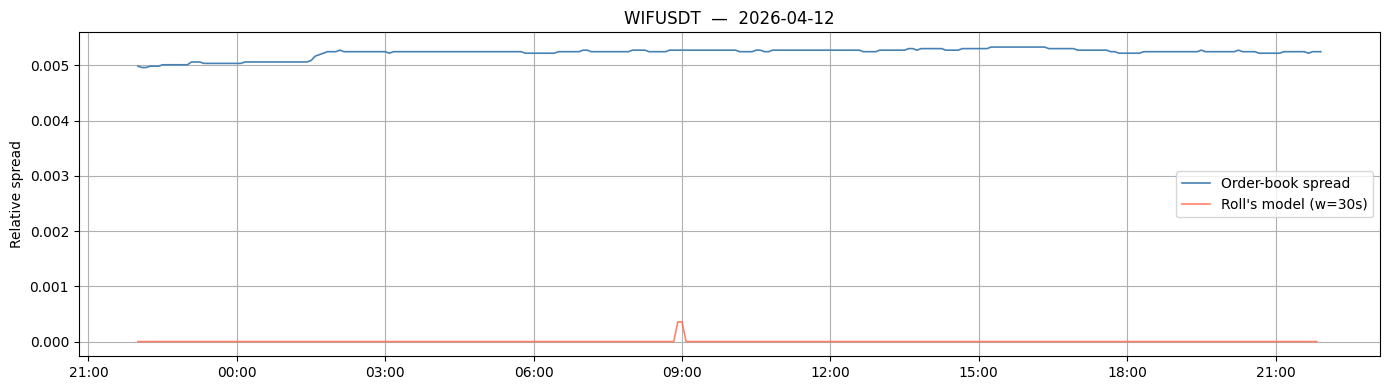

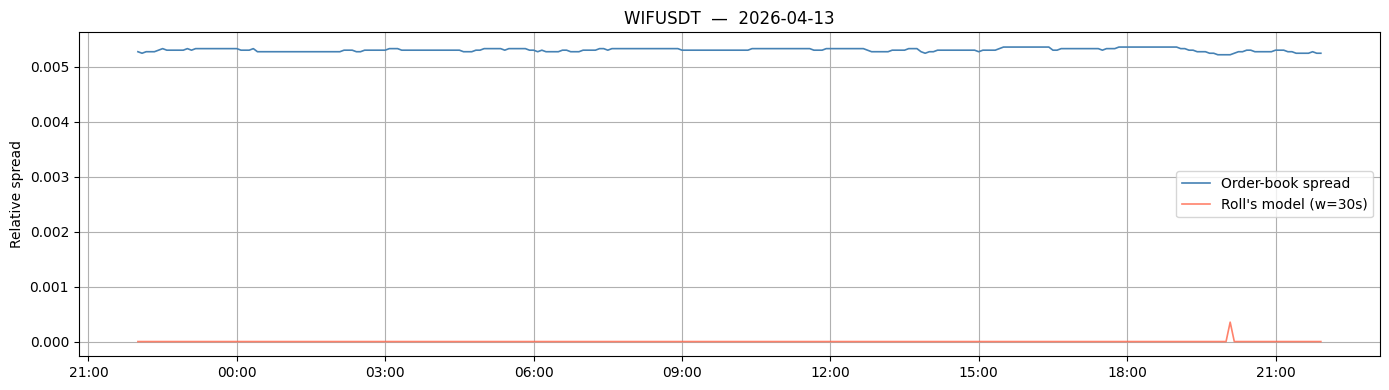

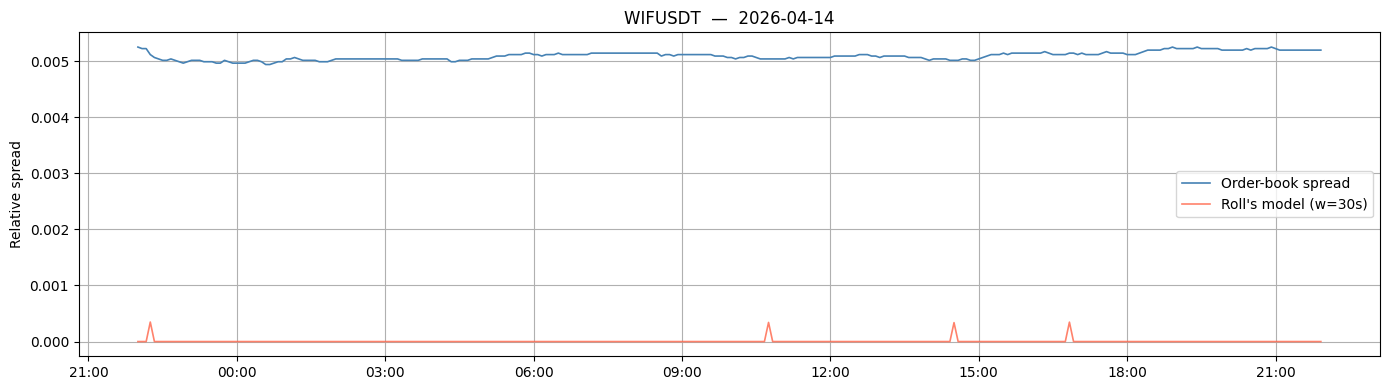

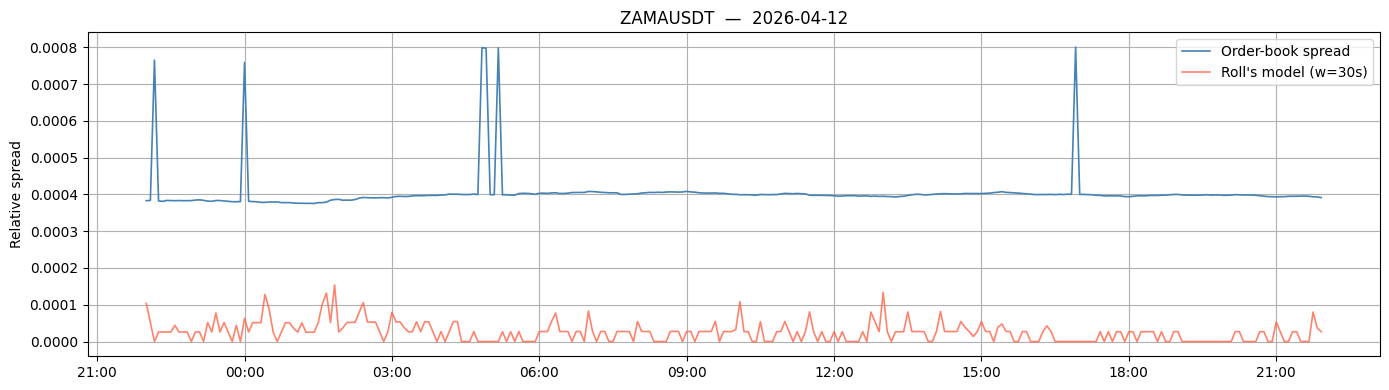

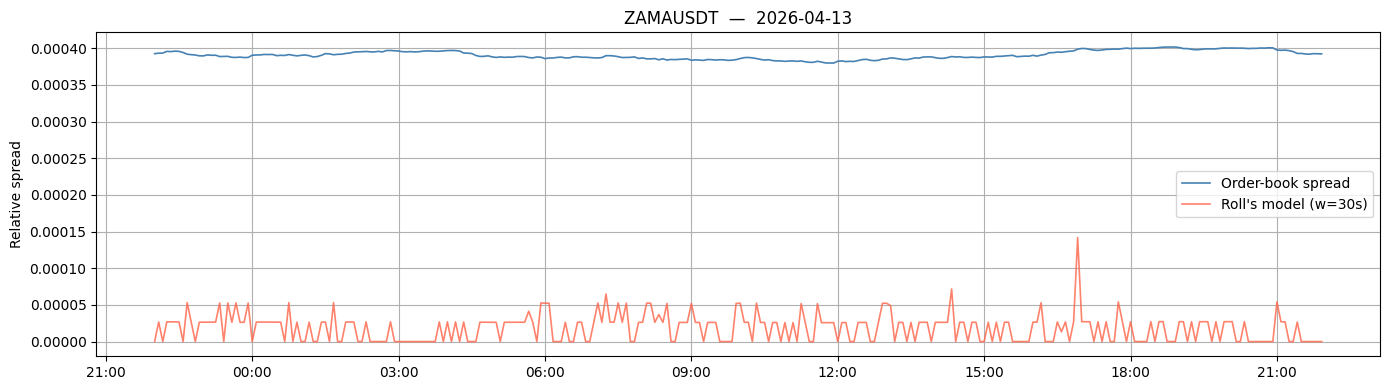

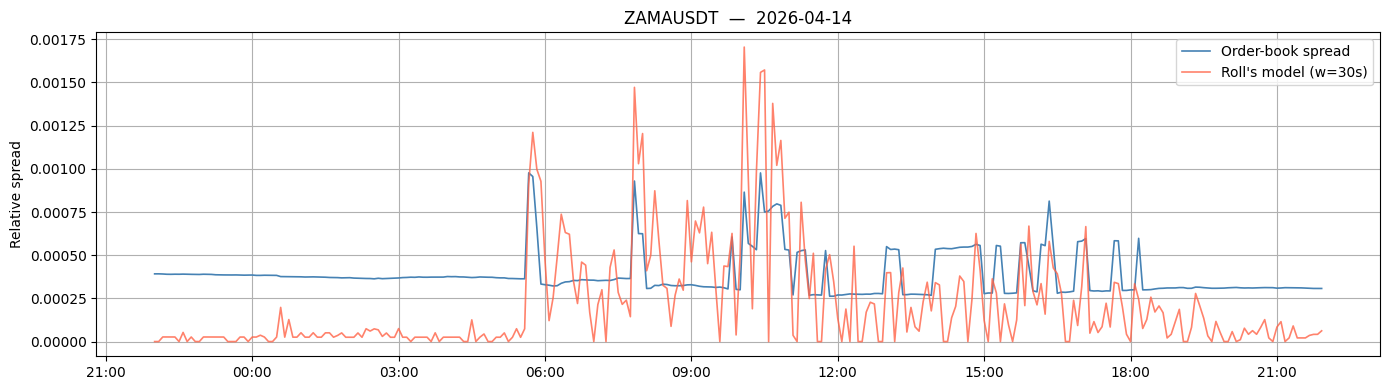

In [12]:
def plot_comparison(ticker, date, window=WINDOW, resample_min='5min'):
    trades = load_trades(ticker, date)
    ob = compute_ob_spread(ticker, date)
    est = estimate_spread(trades['price'], trades['amount'], window=window)

    # smooth to 5-minute for readability
    est_5m = est.resample(resample_min).median()
    ob_5m  = ob.resample(resample_min).median()

    fig, ax = plt.subplots()
    ax.plot(ob_5m.index, ob_5m.values,  label='Order-book spread', lw=1.2, color='steelblue')
    ax.plot(est_5m.index, est_5m.values, label=f"Roll's model (w={window}s)", lw=1.2, color='tomato', alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_ylabel('Relative spread')
    ax.set_title(f'{ticker}  —  {date}')
    ax.legend()
    fig.tight_layout()
    plt.show()

for ticker in TICKERS:
    for date in DATES:
        plot_comparison(ticker, date)

## 4 — Scatter Plot: Estimated vs Actual

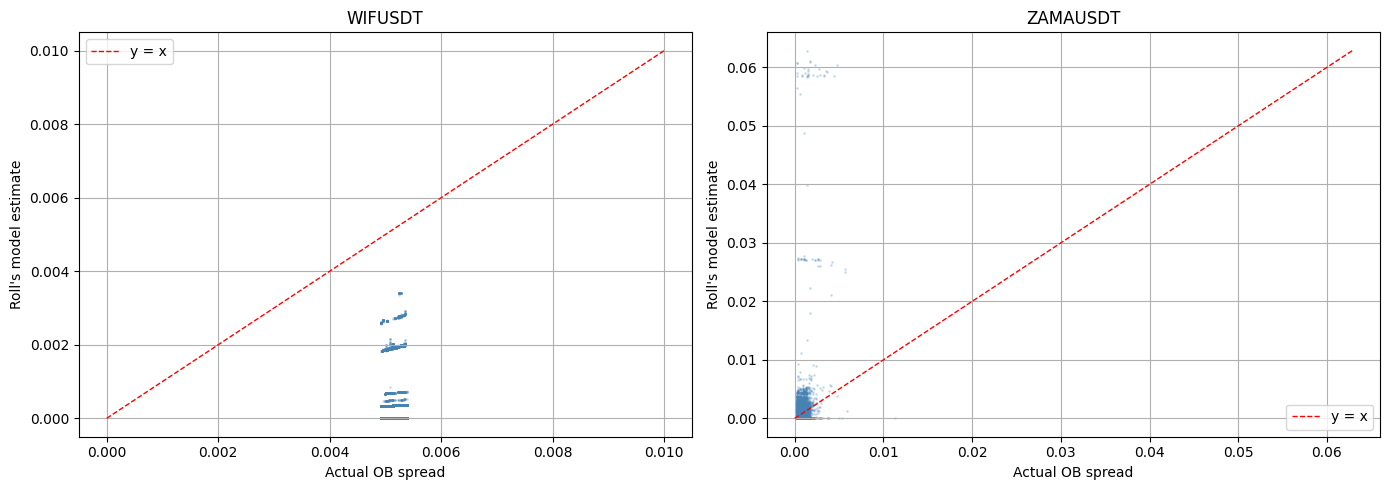

In [13]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(7 * len(TICKERS), 5))

for ax, ticker in zip(axes, TICKERS):
    frames = []
    for date in DATES:
        trades = load_trades(ticker, date)
        ob = compute_ob_spread(ticker, date)
        est = estimate_spread(trades['price'], trades['amount'], window=WINDOW)
        df = pd.concat({'est': est, 'act': ob}, axis=1).dropna()
        frames.append(df)

    combined = pd.concat(frames)
    ax.scatter(combined['act'], combined['est'], s=1, alpha=0.2, color='steelblue')
    lim = max(combined.max().max(), 0.01)
    ax.plot([0, lim], [0, lim], 'r--', lw=1, label='y = x')
    ax.set_xlabel('Actual OB spread')
    ax.set_ylabel("Roll's model estimate")
    ax.set_title(ticker)
    ax.legend()

fig.tight_layout()
plt.show()